# Notebook 02 — Data Cleaning & Unified Schema
**AGD 2026 | AI Workflow Engineer**

Goal: Fix JUT-01 TVD, apply formation tags, build the master DataFrame saved to `data/processed/`.

In [1]:
import sys, warnings, yaml
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

with open("../config/settings.yaml") as f:
    CFG = yaml.safe_load(f)

RAW_DIR      = Path("..") / CFG["paths"]["data"]["raw"]
EXTERNAL_DIR = Path("..") / CFG["paths"]["data"]["external"]
PROC_DIR     = Path("..") / CFG["paths"]["data"]["processed"]
FIG_DIR      = Path("..") / CFG["paths"]["outputs"]["figures"]
PROC_DIR.mkdir(parents=True, exist_ok=True)

from src.pipeline.las_loader import load_all_wells
from src.pipeline.depth_converter import add_tvd_to_vertical_well, load_well_survey, md_to_tvd
from src.pipeline.schema_builder import build_unified_schema

DEVIATED_WELLS = CFG["wells"]["deviated"]
print(f"Deviated wells requiring TVD conversion: {DEVIATED_WELLS}")


Deviated wells requiring TVD conversion: ['JUT-01']


## 1. Load all wells

In [2]:
wells = load_all_wells(RAW_DIR)


Loading 4 LAS files from ..\data\raw



  [BLT-01] Loaded 27,875 rows | Curves: ['bitsize', 'cali', 'casing_flag-(s)gr_nphi_dtc', 'drho', 'dtc', 'dts', 'dtst', 'gr', 'grkt', 'grto', 'nphi', 'pe', 'pota', 'rd', 'rhob', 'rm', 'rs', 'thor', 'uran']


  [EVD-01] Loaded 21,569 rows | Curves: ['gr', 'dt', 'rhob', 'drho']


  [JUT-01] Loaded 22,427 rows | Curves: ['dept:2', 'gr', 'dt', 'rhob']


  [PKP-01] Loaded 27,508 rows | Curves: ['gr', 'dt', 'rhob', 'drho', 'nphi']

Loaded wells: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']


## 2. Add TVD to all wells
- Vertical wells: TVD = MD
- JUT-01 (deviated): interpolate from survey table

In [3]:
SURVEY_PATH = EXTERNAL_DIR / "Well Path Data.xlsx"

for well_name, df in wells.items():
    if well_name in DEVIATED_WELLS:
        print(f"\n{well_name}: loading directional survey for MD→TVD conversion...")
        try:
            survey_df = load_well_survey(SURVEY_PATH, well_name)
            wells[well_name] = md_to_tvd(df, survey_df)
        except Exception as e:
            print(f"  WARNING: TVD conversion failed for {well_name}: {e}")
            print(f"  Falling back to TVD = MD (will over-estimate depths)")
            wells[well_name] = add_tvd_to_vertical_well(df)
    else:
        print(f"{well_name}: vertical well — TVD = MD")
        wells[well_name] = add_tvd_to_vertical_well(df)

print("\nTVD conversion complete for all wells.")


BLT-01: vertical well — TVD = MD
EVD-01: vertical well — TVD = MD

JUT-01: loading directional survey for MD→TVD conversion...


Available sheets in Well Path Data: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']
  Survey columns for JUT-01: ['DEPTH_(M)', 'INCLINATION_(º)', 'AZIMUTH_(º)', 'TVD_(M)', 'X-OFFSET_(M)', 'Y-OFFSET_(M)']
  Using survey columns: MD='DEPTH_(M)', TVD='TVD_(M)'
  TVD interpolated: 6,019 valid values
PKP-01: vertical well — TVD = MD

TVD conversion complete for all wells.


## 3. Build unified schema with formation tags

In [4]:
LITHO_PATH = EXTERNAL_DIR / "Lithostratigraphic Data.xlsx"

unified = build_unified_schema(wells, LITHO_PATH)

print(f"\nUnified DataFrame shape: {unified.shape}")
print(f"Columns: {list(unified.columns)}")
print(f"\nRotliegend rows per well:")
print(unified.groupby("WELL_ID")["is_rotliegend"].sum())


Lithostratigraphic sheets: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']
  BLT-01: 44 formation intervals loaded


  EVD-01: 32 formation intervals loaded
  JUT-01: 47 formation intervals loaded
  PKP-01: 35 formation intervals loaded
Total formation intervals: 158

Building schema for BLT-01...


  [BLT-01] Rotliegend interval: 2,611 rows tagged

Building schema for EVD-01...
  [EVD-01] Rotliegend interval: 4,090 rows tagged

Building schema for JUT-01...


  [JUT-01] Rotliegend interval: 1,597 rows tagged

Building schema for PKP-01...
  [PKP-01] Rotliegend interval: 2,205 rows tagged

Unified schema: 99,379 rows x 14 cols
Wells: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']
Rotliegend rows: 10,503

Unified DataFrame shape: (99379, 14)
Columns: ['WELL_ID', 'DEPTH_M', 'TVD_M', 'gr_api', 'rhob_gcc', 'drho_gcc', 'nphi_vv', 'dt_usft', 'dts_usft', 'rd_ohmm', 'rm_ohmm', 'rs_ohmm', 'formation', 'is_rotliegend']

Rotliegend rows per well:


WELL_ID
BLT-01    2611
EVD-01    4090
JUT-01    1597
PKP-01    2205
Name: is_rotliegend, dtype: int64


## 4. Null analysis on unified DataFrame

In [5]:
curve_cols = [c for c in unified.columns
              if c not in ("WELL_ID","DEPTH_M","TVD_M","formation","is_rotliegend")]

null_pct = unified.groupby("WELL_ID")[curve_cols].apply(
    lambda g: 100 * g.isna().mean()
).round(1)

print("Null % per curve per well (Rotliegend interval only):")
rotl = unified[unified["is_rotliegend"]]
null_rotl = rotl.groupby("WELL_ID")[curve_cols].apply(
    lambda g: 100 * g.isna().mean()
).round(1)
print(null_rotl.to_string())


Null % per curve per well (Rotliegend interval only):
         gr_api  rhob_gcc  drho_gcc  nphi_vv  dt_usft  dts_usft  rd_ohmm  rm_ohmm  rs_ohmm
WELL_ID                                                                                   
BLT-01      3.2       0.0       0.0      0.3     10.1      10.1      2.4      2.4      2.4
EVD-01      0.0      73.9      75.1    100.0      1.5     100.0    100.0    100.0    100.0
JUT-01      0.0      89.0     100.0    100.0      0.0     100.0    100.0    100.0    100.0
PKP-01      1.0       0.7       0.7      0.7      6.9     100.0    100.0    100.0    100.0


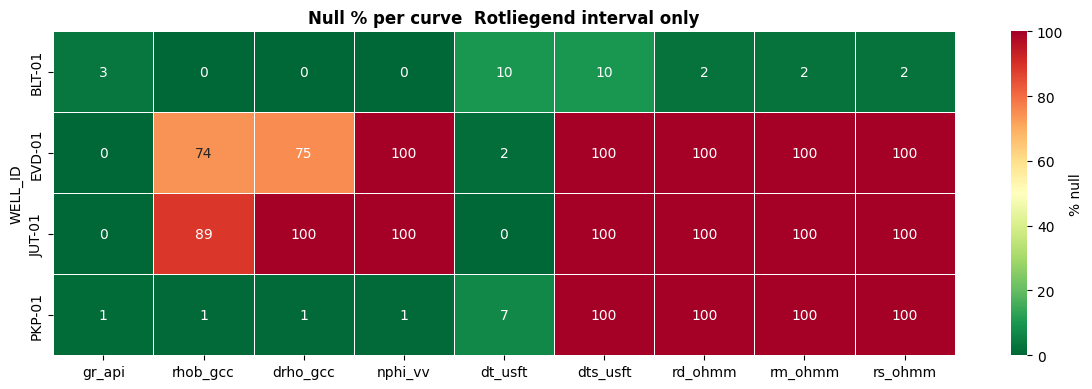

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

if not null_rotl.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(null_rotl, annot=True, fmt=".0f",
                cmap="RdYlGn_r", vmin=0, vmax=100,
                linewidths=0.5, ax=ax,
                cbar_kws={"label": "% null"})
    ax.set_title("Null % per curve  Rotliegend interval only", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "02_null_rotliegend.png", dpi=150, bbox_inches="tight")
    plt.show()


## 5. Formation depth summary

In [7]:
print("Formation depth ranges per well:")
for well in CFG["wells"]["all"]:
    wdf = unified[unified["WELL_ID"] == well]
    forms = wdf.groupby("formation")["TVD_M"].agg(["min","max","count"])
    print(f"\n{well}:")
    print(forms.to_string())


Formation depth ranges per well:

BLT-01:
                                            min        max  count
formation                                                        
Basal Solling Sandstone Member        1435.2270  1449.9336    194
Berg Member                            530.0472   544.9824    197
Boom Member                            462.5340   529.9710    886
Boxtel Formation                         7.2390    14.1732     92
Breda Formation                        297.5610   417.9570   1581
Drenthe Formation                       14.2494    24.1554    131
Fringe Coppershale Member             1920.4686  1923.9738     47
Grey Salt Clay Member                 1843.8114  1844.3448      8
Hellevoetsluis Formation              2052.7518  2093.9760    542
Ieper Member                           545.0586   587.9592    564
Lower Holland Marl Member             1193.0634  1214.7804    286
Lower Muschelkalk Member              1246.8606  1280.1600    438
Lower Röt Fringe Claystone Member 

## 6. Quick QC plot — formation log track

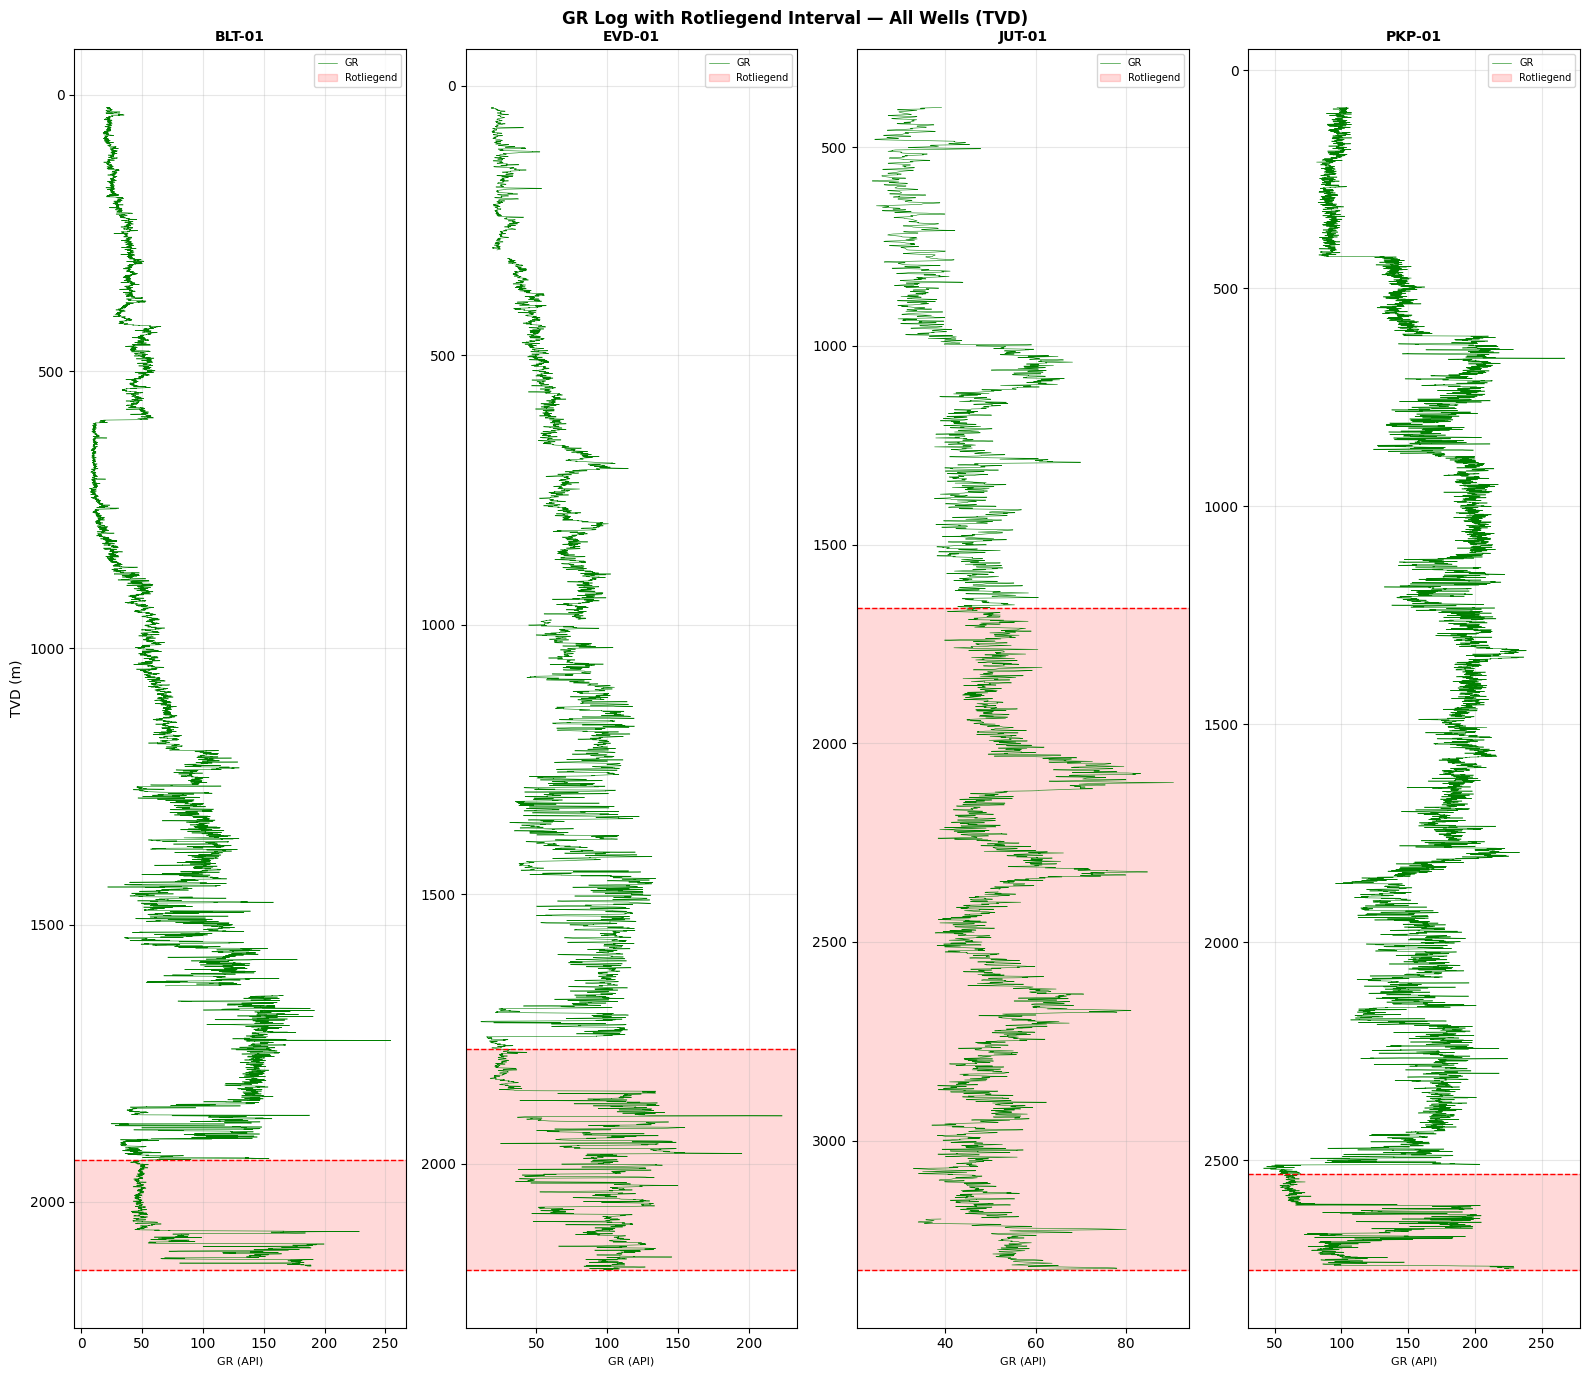

Saved: 02_formation_log_track.png


In [8]:
fig, axes = plt.subplots(1, len(CFG["wells"]["all"]), figsize=(4*len(CFG["wells"]["all"]), 14))

colors = {"Rotliegend": "#e74c3c", "UNKNOWN": "#bdc3c7"}

for ax, well_name in zip(axes, CFG["wells"]["all"]):
    wdf = unified[unified["WELL_ID"] == well_name].copy()
    wdf = wdf.sort_values("TVD_M")

    if "gr_api" in wdf.columns and wdf["gr_api"].notna().any():
        ax.plot(wdf["gr_api"], wdf["TVD_M"], color="green", lw=0.4, label="GR")

    # Shade Rotliegend interval
    rotl_wdf = wdf[wdf["is_rotliegend"]]
    if not rotl_wdf.empty:
        ax.axhspan(rotl_wdf["TVD_M"].min(), rotl_wdf["TVD_M"].max(),
                   alpha=0.15, color="red", label="Rotliegend")
        ax.axhline(rotl_wdf["TVD_M"].min(), color="red", lw=1, ls="--")
        ax.axhline(rotl_wdf["TVD_M"].max(), color="red", lw=1, ls="--")

    ax.invert_yaxis()
    ax.set_title(well_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("GR (API)", fontsize=8)
    if well_name == CFG["wells"]["all"][0]:
        ax.set_ylabel("TVD (m)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("GR Log with Rotliegend Interval — All Wells (TVD)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_formation_log_track.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 02_formation_log_track.png")


## 7. Save processed output

In [9]:
out_path = PROC_DIR / "all_wells_merged.csv"
unified.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Shape: {unified.shape}")
print(f"\nSample rows (Rotliegend):")
print(unified[unified["is_rotliegend"]].head(5).to_string())


Saved: ..\data\processed\all_wells_merged.csv
Shape: (99379, 14)

Sample rows (Rotliegend):
      WELL_ID    DEPTH_M      TVD_M    gr_api  rhob_gcc  drho_gcc   nphi_vv   dt_usft  dts_usft    rd_ohmm    rm_ohmm    rs_ohmm             formation  is_rotliegend
25250  BLT-01  1924.0500  1924.0500  64.78102  2.702533  0.019262  0.138314  60.96968  104.1284  10.136090  10.252800  10.201990  Slochteren Formation           True
25251  BLT-01  1924.1262  1924.1262  63.22850  2.688380  0.018766  0.137186  62.04010  105.0851   8.676470   8.577739   8.416903  Slochteren Formation           True
25252  BLT-01  1924.2024  1924.2024  62.69407  2.670899  0.017066  0.134563  62.98618  105.9891   7.602859   7.239621   6.983837  Slochteren Formation           True
25253  BLT-01  1924.2786  1924.2786  62.77129  2.647428  0.014640  0.128682  63.83451  106.8579   6.858730   6.263126   5.902086  Slochteren Formation           True
25254  BLT-01  1924.3548  1924.3548  62.97287  2.614073  0.011864  0.116835  6